In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_excel('datathon/personal_finance_dataset(without dictionary file).xlsx')

In [14]:
df

,PAGEMIEG,PATTCRU,PATTSITC,PATTSKP,PEDUCMIE,PEFATINC,PFMTYPG,PFTENUR,PLFFPTME,PNBEARG,PPVRES,PWAPRVAL,PWASTDEP,PWATFS,PWDPRMOR,PWDSLOAN,PWDSTCRD,PWDSTLOC,PWNETWPG
0,6,4,3,2,4,115525,4,1,3,2,35,1000000,16000,90000,0,0,0,0,3713000
1,7,4,3,2,9,121300,2,1,3,9,47,625000,2900,15500,0,0,0,145000,1740900
2,5,4,3,2,4,19175,2,1,3,0,48,875000,5000,50000,0,0,0,40000,3672500
3,6,3,3,2,4,147425,2,2,2,2,35,500000,1050,11500,180000,0,18500,10000,2809050
4,4,4,3,2,3,56750,1,3,1,1,35,0,0,0,0,0,0,0,471900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16236,4,4,1,2,4,47175,1,3,1,1,59,0,7000,10500,0,0,0,0,96850
16237,6,4,2,2,2,121925,2,2,1,2,46,700000,280000,100000,28000,0,0,0,1989000
16238,2,4,2,2,4,124425,3,2,1,2,24,250000,8250,9500,82500,30000,0,850,240100
16239,3,4,3,1,3,67625,1,3,1,1,24,0,1550,2100,0,2500,450,0,23750


In [15]:
# Check for missing values
print(df.isnull().sum())

PAGEMIEG    0
PATTCRU     0
PATTSITC    0
PATTSKP     0
PEDUCMIE    0
PEFATINC    0
PFMTYPG     0
PFTENUR     0
PLFFPTME    0
PNBEARG     0
PPVRES      0
PWAPRVAL    0
PWASTDEP    0
PWATFS      0
PWDPRMOR    0
PWDSLOAN    0
PWDSTCRD    0
PWDSTLOC    0
PWNETWPG    0
dtype: int64


In [31]:
print(df.columns)

Index(['PAGEMIEG', 'PATTCRU', 'PATTSITC', 'PATTSKP', 'PEDUCMIE', 'PEFATINC',
       'PFMTYPG', 'PFTENUR', 'PLFFPTME', 'PNBEARG', 'PPVRES', 'PWAPRVAL',
       'PWASTDEP', 'PWATFS', 'PWDPRMOR', 'PWDSLOAN', 'PWDSTCRD', 'PWDSTLOC',
       'PWNETWPG'],
      dtype='object')


In [20]:
# Calculate total debt by summing the individual debt columns
df['total_debt'] = df['PWDSLOAN'] + df['PWDSTCRD'] + df['PWDPRMOR'] + df['PWDSTLOC']

# Calculate Debt-to-Income Ratio (DTI)
df['DTI'] = df['total_debt'] / df['PEFATINC']

# Display the first few rows to check the DTI calculation
df[['PWDSLOAN', 'PWDSTCRD', 'PWDPRMOR', 'PWDSTLOC', 'PEFATINC', 'total_debt', 'DTI']]

,PWDSLOAN,PWDSTCRD,PWDPRMOR,PWDSTLOC,PEFATINC,total_debt,DTI
0,0,0,0,0,115525,0,0.000000
1,0,0,0,145000,121300,145000,1.195383
2,0,0,0,40000,19175,40000,2.086050
3,0,18500,180000,10000,147425,208500,1.414278
4,0,0,0,0,56750,0,0.000000
...,...,...,...,...,...,...,...
16236,0,0,0,0,47175,0,0.000000
16237,0,0,28000,0,121925,28000,0.229649
16238,30000,0,82500,850,124425,113350,0.910991
16239,2500,450,0,0,67625,2950,0.043623


In [31]:
!pip install seaborn


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [41]:
# Check the minimum and maximum DTI values
print(df['DTI'].min(), df['DTI'].max())


-50.0 inf


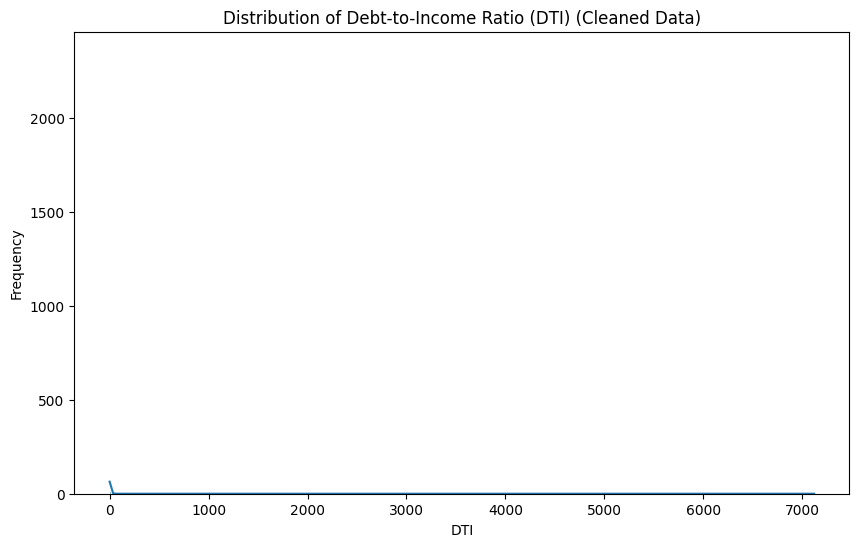

In [42]:
# Remove rows where DTI is negative or infinite
df_cleaned = df[(df['DTI'] > 0) & (df['DTI'] != np.inf)]

# Plot the distribution of valid DTI values
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned['DTI'], kde=True)
plt.title('Distribution of Debt-to-Income Ratio (DTI) (Cleaned Data)')
plt.xlabel('DTI')
plt.ylabel('Frequency')
plt.show()

In [38]:
# Recalculate the DTI column (ensure debt and income columns exist)
df['DTI'] = (df['PWDSLOAN'] + df['PWDSTCRD'] + df['PWDPRMOR'] + df['PWDSTLOC']) / df['PEFATINC']

# Display the first few rows to check the DTI calculation
print(df[['PWDSLOAN', 'PWDSTCRD', 'PWDPRMOR', 'PWDSTLOC', 'PEFATINC', 'DTI']])
import numpy as np  # Import NumPy

       PWDSLOAN  PWDSTCRD  PWDPRMOR  PWDSTLOC  PEFATINC       DTI
0             0         0         0         0    115525  0.000000
1             0         0         0    145000    121300  1.195383
2             0         0         0     40000     19175  2.086050
3             0     18500    180000     10000    147425  1.414278
4             0         0         0         0     56750  0.000000
...         ...       ...       ...       ...       ...       ...
16236         0         0         0         0     47175  0.000000
16237         0         0     28000         0    121925  0.229649
16238     30000         0     82500       850    124425  0.910991
16239      2500       450         0         0     67625  0.043623
16240         0      6750    170000      6500    152350  1.202822

[16241 rows x 6 columns]


In [43]:
# Remove rows where DTI is negative or infinite
df_cleaned = df[(df['DTI'] > 0) & (df['DTI'] != np.inf)]

# Check if the cleaned data has valid DTI values
print(df_cleaned['DTI'])

1        1.195383
2        2.086050
3        1.414278
5        0.194986
7        0.053797
           ...   
16235    1.953488
16237    0.229649
16238    0.910991
16239    0.043623
16240    1.202822
Name: DTI, Length: 9368, dtype: float64


In [15]:
# Check the minimum and maximum values of the cleaned DTI
print(df_cleaned['DTI'].min(), df_cleaned['DTI'].max())

1.819505094614265e-05 7121.0


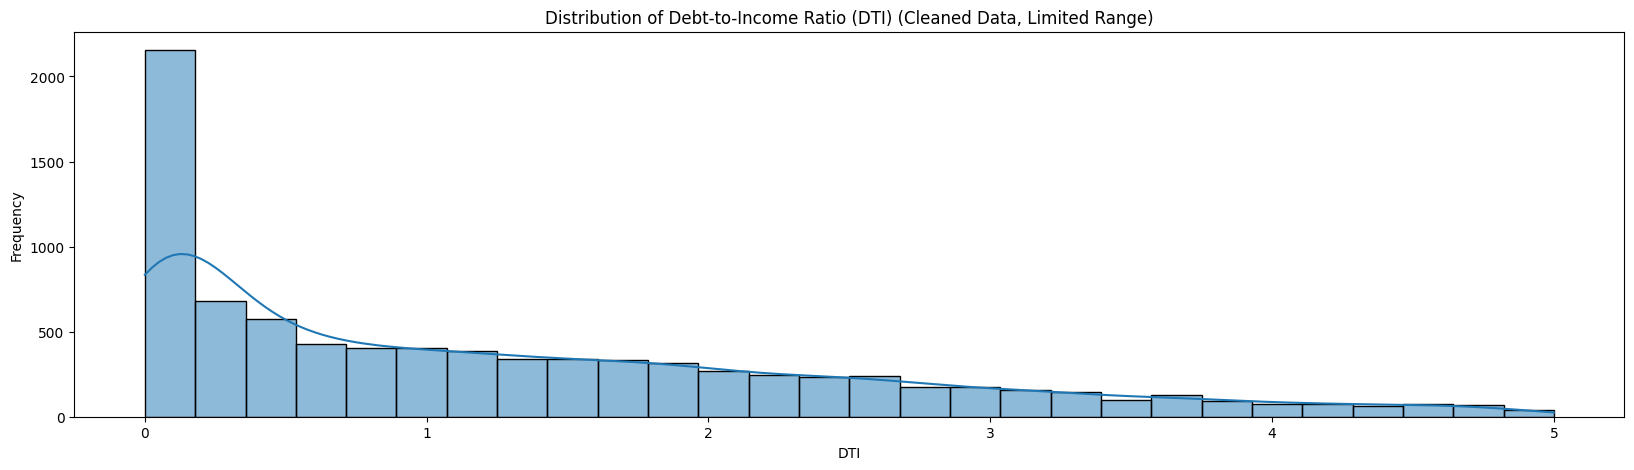

In [44]:
# Limit the DTI values to a maximum of 10 for better visualization
plt.figure(figsize=(20, 5))
sns.histplot(df_cleaned[df_cleaned['DTI'] <= 5]['DTI'], kde=True)
plt.title('Distribution of Debt-to-Income Ratio (DTI) (Cleaned Data, Limited Range)')
plt.xlabel('DTI')
plt.ylabel('Frequency')
plt.show()

In [45]:
# Check how many rows are left after cleaning the data
print(df_cleaned.shape)

(9368, 20)


In [46]:
print(df.columns)


Index(['PAGEMIEG', 'PATTCRU', 'PATTSITC', 'PATTSKP', 'PEDUCMIE', 'PEFATINC',
       'PFMTYPG', 'PFTENUR', 'PLFFPTME', 'PNBEARG', 'PPVRES', 'PWAPRVAL',
       'PWASTDEP', 'PWATFS', 'PWDPRMOR', 'PWDSLOAN', 'PWDSTCRD', 'PWDSTLOC',
       'PWNETWPG', 'DTI'],
      dtype='object')
